In [284]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [285]:
#from google.colab import files
#uploaded = files.upload()

In [286]:
data=pd.read_csv("student_habits_performance.csv")


In [287]:
#annalyse descriptive de notre dataset
print(f"dimension de notre dataset: {data.shape}")
print("")

print("entete de notre dataset : les 10 prémières lignes :")
print(data.head(10))
print("")


print(f"information générale")
print(data.info())

dimension de notre dataset: (1000, 16)

entete de notre dataset : les 10 prémières lignes :
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   
5      S1005   24    Male                  7.2                 1.3   
6      S1006   21  Female                  5.6                 1.5   
7      S1007   21  Female                  4.3                 1.0   
8      S1008   23  Female                  4.4                 2.2   
9      S1009   18  Female                  4.8                 3.1   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0 

In [288]:
print("vérification des lignes  dupliquées dans notre dataset: ",data.duplicated().sum()," lignes dupliquées")


vérification des lignes  dupliquées dans notre dataset:  0  lignes dupliquées


In [289]:
#suppression de la colonne student_id
data=data.drop(columns=["student_id"])

In [290]:
print("vérification des valeurs manquantes:")
print(data.isnull().sum())

vérification des valeurs manquantes:
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [291]:
print("pourcentage des valeurs manquantes par colonne:")
print(data.isnull().mean()*100)

pourcentage des valeurs manquantes par colonne:
age                              0.0
gender                           0.0
study_hours_per_day              0.0
social_media_hours               0.0
netflix_hours                    0.0
part_time_job                    0.0
attendance_percentage            0.0
sleep_hours                      0.0
diet_quality                     0.0
exercise_frequency               0.0
parental_education_level         9.1
internet_quality                 0.0
mental_health_rating             0.0
extracurricular_participation    0.0
exam_score                       0.0
dtype: float64


In [292]:
#informaton sur la colonne des valeurs manquantes
data["parental_education_level"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: parental_education_level
Non-Null Count  Dtype 
--------------  ----- 
909 non-null    object
dtypes: object(1)
memory usage: 7.9+ KB


In [293]:
# Vérifons si une colonne de notre dataset est colérée avec les valeurs manquantes
df=data.dropna()
print(f"nouvelle dimension:{df.shape}")

# encodage des variables catégorielles nominales
df=pd.get_dummies(data,columns=["gender"],drop_first=True)
df["part_time_job"]=(data["part_time_job"]=="Yes").astype(int)
df["extracurricular_participation"]=(data["extracurricular_participation"]=="Yes").astype(int)


#encodage des valeurs catégorielle ordinales
diet_map={"Poor": 1,"Fair":2, "Good":2}
p_map={"High School": 1,"Bachelor":2, "Master":3}
internet_map={"Poor": 1,"Average":2, "Good":3}

df["parental_education_level"]=data["parental_education_level"].map(p_map)
df["internet_quality"]=data["internet_quality"].map(internet_map)
df["diet_quality"]=data["diet_quality"].map(diet_map)




nouvelle dimension:(909, 15)


In [294]:
#matrice de corrélation
correlation = df.corr()
print(correlation)

                                    age  study_hours_per_day  \
age                            1.000000             0.003971   
study_hours_per_day            0.003971             1.000000   
social_media_hours            -0.009151             0.020282   
netflix_hours                 -0.001174            -0.031158   
part_time_job                 -0.011680            -0.029133   
attendance_percentage         -0.026055             0.026264   
sleep_hours                    0.037482            -0.027757   
diet_quality                   0.010192             0.066777   
exercise_frequency            -0.003836            -0.028701   
parental_education_level       0.027578             0.001925   
internet_quality               0.007799             0.014459   
mental_health_rating          -0.045101            -0.003768   
extracurricular_participation -0.004993            -0.003264   
exam_score                    -0.008907             0.825419   
gender_Male                    0.025562 

In [295]:
correlation["parental_education_level"]

,parental_education_level
age,0.027578
study_hours_per_day,0.001925
social_media_hours,-0.016840
netflix_hours,-0.020531
part_time_job,-0.034099
attendance_percentage,-0.029672
sleep_hours,0.017303
diet_quality,-0.023301
exercise_frequency,-0.041687
parental_education_level,1.000000


In [296]:
# d'après l'annalyse , il n'y a pas de corrélation avec les autres colonnes
#donc nous allons remplacer les valeurs manquantes par le mode

print("d'après l'annalyse , il n'y a pas de corrélation avec les autres colonnes donc nous allons remplacer les valeurs manquantes par le mode")

d'après l'annalyse , il n'y a pas de corrélation avec les autres colonnes donc nous allons remplacer les valeurs manquantes par le mode


In [297]:
# remplaçons nos valeurs manquantes par le mode
data["parental_education_level"]=data["parental_education_level"].fillna(data["parental_education_level"].mode()[0])

In [298]:
# vérifions si nos valeurs manquantes ont été bien remplacé:
data.isnull().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


In [299]:
# vérifions si nous avons des valeurs abérrantes dans notre dataset
data.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [300]:
# encodage des variables catégorielles nominales
data=pd.get_dummies(data,columns=["gender"],drop_first=True)
data["part_time_job"]=(data["part_time_job"]=="Yes").astype(int)
data["extracurricular_participation"]=(data["extracurricular_participation"]=="Yes").astype(int)


In [301]:
#encodage des valeurs catégorielle ordinales
diet_map={"Poor": 1,"Fair":2, "Good":2}
p_map={"High School": 1,"Bachelor":2, "Master":3}
internet_map={"Poor": 1,"Average":2, "Good":3}

data["parental_education_level"]=data["parental_education_level"].map(p_map)
data["internet_quality"]=data["internet_quality"].map(internet_map)
data["diet_quality"]=data["diet_quality"].map(diet_map)

In [302]:
# séparation en features et variables cibles
X=data.drop(columns=["exam_score"])
Y=data["exam_score"].values

In [303]:
# fonction de normalisation (retourne aussi mean et std pour normaliser le test)
def normalisation(X, mean=None, std=None):
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
    return (X - mean) / std, mean, std


In [304]:
#sépartion pour l'entrainement
np.random.seed(42)
indices=np.random.permutation(len(X))

split=int(0.8*len(X))
train_idx=indices[:split]
test_idx=indices[split:]

x_train,x_test=X.iloc[train_idx],X.iloc[test_idx]
y_train,y_test=Y[train_idx],Y[test_idx]


In [305]:
#biais

def biais(x):
    m=x.shape[0]
    return np.hstack([np.ones((m,1)),x])


#fonction de prédiction

def prediction(x,w):
    return x@w


#fonction de calcul de l'erreur quadratique moyen mse

def mse(y,y_pred):
    m=len(y)
    return (np.sum((y-y_pred)**2))/m


#calcul du gradient

def gradient (x,y,y_pred):
    taille=len(y)
    residus=y-y_pred
    grad=-(2/taille)*(x.T@residus)

    return grad


#déscente du gradient

def desc_gradient(x,y,pas=0.1,iteration=2000):
    w=np.zeros(x.shape[1])
    tab_cout=[]

    for i in range(iteration):
        y_pred=prediction(x,w)
        grad=gradient(x,y,y_pred)
        cout=mse(y,y_pred)
        tab_cout.append(cout)
        w=w-pas*grad

    return w,tab_cout


In [306]:
# normalisation (sans biais) — on garde mean/std du train pour normaliser le test
x_train_n, train_mean, train_std = normalisation(x_train)
x_test_n, _, _ = normalisation(x_test, mean=train_mean, std=train_std)

# ajout du biais
x_train_b = biais(x_train_n)
x_test_b  = biais(x_test_n)

# entraînement
w, tab_cout = desc_gradient(x_train_b, y_train, pas=0.3, iteration=100)

# évaluation train
y_pred_train = prediction(x_train_b, w)
mse_train    = mse(y_train, y_pred_train)
ss_res_train = np.sum((y_train - y_pred_train)**2)
ss_tot_train = np.sum((y_train - y_train.mean())**2)
R2_train     = 1 - ss_res_train/ss_tot_train

# évaluation test
y_pred_test = prediction(x_test_b, w)
mse_test    = mse(y_test, y_pred_test)
ss_res_test = np.sum((y_test - y_pred_test)**2)
ss_tot_test = np.sum((y_test - y_test.mean())**2)
R2_test     = 1 - ss_res_test/ss_tot_test

print(f"entrainement --> mse={mse_train:.4f} | R2={R2_train:.4f}")
print(f"test         --> mse={mse_test:.4f} | R2={R2_test:.4f}")


entrainement --> mse=26.4905 | R2=0.9083
test         --> mse=35.9966 | R2=0.8656


(800, 15)
(800, 30)
(200, 30)


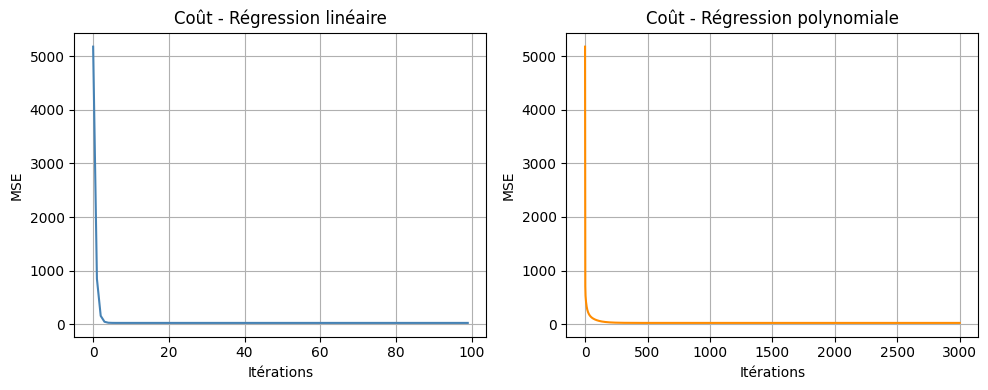

========== COMPARAISON ==========
Linéaire   --> MSE train=26.4905 | R2 train=0.9083
Linéaire   --> MSE test =35.9966  | R2 test =0.8656

Polynomial --> MSE train=25.5208 | R2 train=0.9116
Polynomial --> MSE test =35.0336  | R2 test =0.8692


In [307]:
def polynome(X):
    X_carre = X**2
    return np.hstack([X, X_carre])

# normalisation avant polynome — réutilise mean/std du train
x_train_n2, train_mean2, train_std2 = normalisation(x_train)
x_test_n2, _, _ = normalisation(x_test, mean=train_mean2, std=train_std2)

# features polynomiales
x_train_poly = polynome(x_train_n2)
x_test_poly  = polynome(x_test_n2)

# vérification
print(x_train.shape)
print(x_train_poly.shape)
print(x_test_poly.shape)

# biais
x_train_poly_b = biais(x_train_poly)
x_test_poly_b  = biais(x_test_poly)

# entraînement
w_poly, tab_cout_poly = desc_gradient(x_train_poly_b, y_train, pas=0.02, iteration=3000)

# évaluation train
y_pred_train_poly = prediction(x_train_poly_b, w_poly)
mse_train_poly    = mse(y_train, y_pred_train_poly)
R2_train_poly     = 1 - np.sum((y_train - y_pred_train_poly)**2) / np.sum((y_train - y_train.mean())**2)

# évaluation test
y_pred_test_poly = prediction(x_test_poly_b, w_poly)
mse_test_poly    = mse(y_test, y_pred_test_poly)
R2_test_poly     = 1 - np.sum((y_test - y_pred_test_poly)**2) / np.sum((y_test - y_test.mean())**2)

# évolution du coût
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(tab_cout, color='steelblue')
plt.title("Coût - Régression linéaire")
plt.xlabel("Itérations")
plt.ylabel("MSE")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(tab_cout_poly, color='darkorange')
plt.title("Coût - Régression polynomiale")
plt.xlabel("Itérations")
plt.ylabel("MSE")
plt.grid(True)

plt.tight_layout()
plt.show()

# comparaison
print("========== COMPARAISON ==========")
print(f"Linéaire   --> MSE train={mse_train:.4f} | R2 train={R2_train:.4f}")
print(f"Linéaire   --> MSE test ={mse_test:.4f}  | R2 test ={R2_test:.4f}")
print()
print(f"Polynomial --> MSE train={mse_train_poly:.4f} | R2 train={R2_train_poly:.4f}")
print(f"Polynomial --> MSE test ={mse_test_poly:.4f}  | R2 test ={R2_test_poly:.4f}")


In [308]:
# --- Construction du modèle linéaire
model = keras.Sequential([
    layers.Dense(1, input_shape=(x_train_n.shape[1],), use_bias=True)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [309]:
# --- Compilation ---
# Optimiseur SGD
optimizer = keras.optimizers.SGD(learning_rate=0.05)
model.compile(optimizer=optimizer, loss='mse', metrics=['mse'])


In [310]:
# --- Entraînement ---
history = model.fit(
    x_train_n, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(x_test_n, y_test),
    verbose=1
)


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1137.4899 - mse: 1137.4899 - val_loss: 60.0693 - val_mse: 60.0693
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32.9394 - mse: 32.9394 - val_loss: 35.6237 - val_mse: 35.6237
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.7730 - mse: 27.7730 - val_loss: 35.5999 - val_mse: 35.5999
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.4978 - mse: 27.4978 - val_loss: 36.2107 - val_mse: 36.2107
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.5987 - mse: 27.5987 - val_loss: 35.4943 - val_mse: 35.4943
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.7518 - mse: 27.7518 - val_loss: 35.8412 - val_mse: 35.8412
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27.4582 - mse: 27.4582 - val_loss: 36.9803 - val_mse: 36.9803
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27.4854 - mse: 27.4854 - val_loss: 37.0503 - val_mse: 37.0503
Epoch 9/100
25/25 ━━━━━━━━━

In [311]:
# --- Évaluation ---
train_loss = model.evaluate(x_train_n, y_train, verbose=0)
test_loss = model.evaluate(x_test_n, y_test, verbose=0)

print(f"\nMSE sur l'entraînement (TensorFlow) : {train_loss[0]:.4f}")
print(f"MSE sur le test (TensorFlow)        : {test_loss[0]:.4f}")



MSE sur l'entraînement (TensorFlow) : 26.6910
MSE sur le test (TensorFlow)        : 36.6984


In [312]:
# --- Calcul du R² ---
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

y_train_pred_tf = model.predict(x_train_n, verbose=0).flatten()
y_test_pred_tf = model.predict(x_test_n, verbose=0).flatten()

r2_train_tf = r2_score(y_train, y_train_pred_tf)
r2_test_tf = r2_score(y_test, y_test_pred_tf)

print(f"R² entraînement (TensorFlow) : {r2_train_tf:.4f}")
print(f"R² test (TensorFlow)         : {r2_test_tf:.4f}")


R² entraînement (TensorFlow) : 0.9076
R² test (TensorFlow)         : 0.8630


In [313]:
# --- Comparaison avec la descente de gradient
print("\n========== COMPARAISON FINALE ==========")
print(f"Manuel (linéaire)   --> MSE train={mse_train:.4f} | R2 train={R2_train:.4f}")
print(f"Manuel (linéaire)   --> MSE test ={mse_test:.4f}  | R2 test ={R2_test:.4f}")
print(f"TensorFlow (linéaire)--> MSE train={train_loss[0]:.4f} | R2 train={r2_train_tf:.4f}")
print(f"TensorFlow (linéaire)--> MSE test ={test_loss[0]:.4f}  | R2 test ={r2_test_tf:.4f}")



========== COMPARAISON FINALE ==========
Manuel (linéaire)   --> MSE train=26.4905 | R2 train=0.9083
Manuel (linéaire)   --> MSE test =35.9966  | R2 test =0.8656
TensorFlow (linéaire)--> MSE train=26.6910 | R2 train=0.9076
TensorFlow (linéaire)--> MSE test =36.6984  | R2 test =0.8630


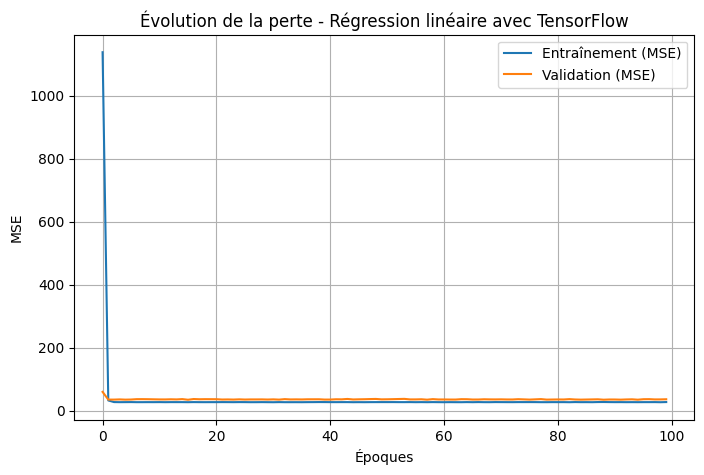

In [314]:
# --- Courbe d'apprentissage ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Entraînement (MSE)')
plt.plot(history.history['val_loss'], label='Validation (MSE)')
plt.title('Évolution de la perte - Régression linéaire avec TensorFlow')
plt.xlabel('Époques')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

